# How this notebook is laid out - Picking-Time Neural Network

1) First load required packages (added Pytorch)
2) Generate Dataset (run once)
3) Train a Decision Tree Classifier
4) Plot Training vs Cross-Validation Accuracy
5) Answers to questions in tasks 1, 2, and 5 are provided inline within the cells below


In [9]:
# Verify required packages are available
import sys
import subprocess
print(f"Python version: {sys.version}")

try:
    import numpy as np
    print(f"✓ numpy {np.__version__} is available")
except ImportError as e:
    print(f"✗ numpy not available: {e}")

try:
    import pandas as pd
    print(f"✓ pandas {pd.__version__} is available")
except ImportError as e:
    print(f"✗ pandas not available: {e}")

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib is available")
except ImportError as e:
    print(f"✗ matplotlib not available: {e}")

try:
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__} is available")
except ImportError as e:
    print(f"✗ scikit-learn not available: {e}")
    print("Installing scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "scikit-learn"] )

try:
    import torch
except ImportError:
    print("PyTorch not found. Installing torch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "torch"] )
    import torch

print(f"✓ PyTorch {torch.__version__} is available")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ PyTorch loaded on: {device}")

print("All required packages are ready!")

Python version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
✓ numpy 2.4.1 is available
✓ pandas 3.0.1 is available
✓ matplotlib is available
✓ scikit-learn 1.8.0 is available
PyTorch not found. Installing torch...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 67.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 75.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 20.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [torch]m 9/10 [torch]]x]s]
✓ PyTorch 2.11.0 is available
✓ PyTorch loaded on: cpu
All required packages are ready!


In [5]:
def generate_picking_time_dataset(n=400, seed=42):
    """Generate warehouse picking-time dataset with nonlinear effects.
    Returns (X, y, feature_names) where X has shape (n, 5).
    """
    rng = np.random.default_rng(seed)
    # --- Sample features ---
    distance    = rng.uniform(2, 30, n)          # meters
    load        = rng.uniform(1, 50, n)          # kg
    congestion  = rng.poisson(1.5, n).astype(float)  # count
    battery     = rng.beta(5, 2, n)              # [0, 1], skewed high
    aisle_width = rng.uniform(1.5, 3.0, n)       # meters
    # --- True relationship ---
    y = (
        5.0                                     # base picking time (seconds)
        + 0.8 * distance                        # linear: farther = slower
        + 0.15 * load                           # linear: heavier = slower
        + 0.4 * congestion * distance           # NONLINEAR: interaction term
        + 12.0 * (battery < 0.2).astype(float)  # NONLINEAR: threshold effect
        - 2.0 * aisle_width                     # linear: wider aisle = faster
        + 0.01 * distance ** 2                  # NONLINEAR: mild quadratic
    )
    # --- Observation noise ---
    y = y + rng.normal(0, 2.0, n)
    # --- Assemble feature matrix ---
    X = np.column_stack([distance, load, congestion, battery, aisle_width])
    feature_names = ["distance", "load", "congestion", "battery", "aisle_width"]
    return X, y, feature_names

#Generate and inspect the dataset
X, y, names = generate_picking_time_dataset(n=400, seed=42)
print(f"Dataset shape: X = {X.shape}, y = {y.shape}")
print(f"Features: {names}")
print(f"Target range: [{y.min():.1f}, {y.max():.1f}], mean = {y.mean():.1f} sec")

#Save to disk

np.savez(
    "picking_time_data.npz",
    X=X, y=y, feature_names=names,
)
print("Saved picking_time_data.npz")

Dataset shape: X = (400, 5), y = (400,)
Features: ['distance', 'load', 'congestion', 'battery', 'aisle_width']
Target range: [-0.1, 93.8], mean = 29.5 sec
Saved picking_time_data.npz


## Dataset

Download **`picking_time_data.npz`** (generated by `generate_dataset.py`).

The dataset contains **400 warehouse picking-time observations** with **5 features**:

- **Distance** (meters)
- **Load** (kilograms)
- **Congestion** (number of robots in the aisle)
- **Battery level**
- **Aisle width** (meters)

The true relationship includes **nonlinear effects** that you will discover empirically.

---

### Loading the dataset

```python
import numpy as np

data = np.load("picking_time_data.npz")
X = data["X"]
y = data["y"]

In [6]:
import numpy as np
data = np.load("picking_time_data.npz")
X, y = data["X"], data["y"]           # (400, 5) and (400,)
feature_names = list(data["feature_names"])

## Task 1: Data Preparation and Validation Strategy

Load and prepare the data as follows:

- Hold out **20%** of the data as a **final test set**  
  - This test set must **never** be used during training or model selection.
- Use the remaining **80%** of the data for **5‑fold cross‑validation**  
  - See *Section 5.2.11: K‑Fold Cross‑Validation*.

For each cross‑validation fold:

- **Normalize input features** to zero mean and unit variance  
  - Fit normalization **only on the fold’s training data**.
- **Normalize target values** in the same way  
  - Again, fit using the training portion of the fold only.

Finally:

- Create a **PyTorch `DataLoader`** with a **batch size of 32**.

In [7]:
data = np.load("picking_time_data.npz")
X_all, y_all = data["X"], data["y"]
# Shuffle and split: 20% held-out test, 80% for cross-validation
n = len(X_all)
idx = np.random.default_rng(0).permutation(n)
n_test = int(0.2 * n)
X_test_raw  = X_all[idx[:n_test]]
y_test_raw  = y_all[idx[:n_test]]
X_cv_raw    = X_all[idx[n_test:]]
y_cv_raw    = y_all[idx[n_test:]]
print(f"Cross-validation pool: {len(X_cv_raw)} examples")
print(f"Held-out test set:     {len(X_test_raw)} examples")

Cross-validation pool: 320 examples
Held-out test set:     80 examples


## Normalization and Training Pipeline

### Normalization

As discussed in [@ml3:gradient-descent-python], features on different scales (e.g., distance in \[2, 30\] vs. battery level in \[0, 1\]) lead to a **poorly conditioned loss landscape**.

To address this, we normalize **both features and targets** to **zero mean and unit variance**.

**Crucially**:
- Normalization statistics are computed **using the training fold only**
- The same statistics are then applied to the corresponding validation fold

This procedure **prevents data leakage**, which would otherwise result in **optimistically biased error estimates**.

---

### DataLoader

PyTorch’s `DataLoader` handles **mini-batch sampling** and **shuffling**.

- A **batch size of 32** is:
  - Small enough for this dataset
  - Large enough to yield **stable gradient estimates** ([@dl2:sgd-revisited])

---

### Task 2: Model Architecture - Build a 3-hidden-layer network

The architecture follows the **feedforward neural network** definition from [@def:feedforward-network].

- Each hidden layer applies the transformation defined in [@eq:layer-computation]
- The **output layer uses no activation function (identity)** because this is a **regression task**
  - The model must predict **any real-valued picking time**, not probabilities

PyTorch implementation details:

- `nn.Linear` uses **Kaiming (He) initialization** by default ([@dl2:weight-initialization])
  - This is appropriate for **ReLU activations**
- `nn.Sequential` is used for **conciseness**, following the XOR PyTorch example ([@dl2b:xor-pytorch])

---

### Task 3: Training Loop - Train for 200 Epochs per fold

The training loop follows the pattern established in [@dl2b]:

1. **Forward pass**  
   `pred = model(X_batch)`

2. **Compute loss**  
   `loss = criterion(pred, y_batch)`  
   - Mean Squared Error (MSE, [@ml3:mse-loss])

3. **Zero gradients**  
   `optimizer.zero_grad()`

4. **Backward pass**  
   `loss.backward()`  
   - Backpropagation ([@dl2:backpropagation])

5. **Update weights**  
   `optimizer.step()`  
   - Adam optimizer ([@dl2:optimizers])

We use:
- `model.train()` and `model.eval()` to toggle training and evaluation behavior  
  - Dropout and batch normalization are not used here, but this is **best practice**
- `torch.no_grad()` during validation  
  - Saves memory and computation since gradients are unnecessary during evaluation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Normalization
def normalize(X_train, y_train, X_val, y_val):
    """Normalize features and targets using training-set statistics."""
    X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
    y_mean, y_std = y_train.mean(), y_train.std()
    return (
        (X_train - X_mean) / X_std,  # normalized train features
        (y_train - y_mean) / y_std,   # normalized train targets
        (X_val   - X_mean) / X_std,   # normalized val features (same stats!)
        (y_val   - y_mean) / y_std,   # normalized val targets
        X_mean, X_std, y_mean, y_std, # save stats for denormalization later
    )

# Data Loader with batch size = 32
def make_loader(X, y, batch_size=32, shuffle=True):
    """Wrap NumPy arrays in a PyTorch DataLoader."""
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1),  # (N,) -> (N,1)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# Task 2: Model Definition
def make_model(n_hidden_layers=3):
    """Create a feedforward network with variable depth.
    Uses widths [32, 16, 8], truncated to n_hidden_layers.
    This lets us compare depths in the experiment below.
    """
    widths = [32, 16, 8][:n_hidden_layers]
    layers = []
    d_in = 5  # number of input features
    for w in widths:
        layers.append(nn.Linear(d_in, w))  # linear transform: W @ a + b
        layers.append(nn.ReLU())           # element-wise activation
        d_in = w
    layers.append(nn.Linear(d_in, 1))      # output layer (no activation)
    return nn.Sequential(*layers)

# Task 3: Training Function where epochs set to 200 per fold
def train_model(model, train_loader, X_val_t, y_val_t,
                epochs=200, lr=1e-3):
    """Train a model and return per-epoch (train_losses, val_losses)."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        # --- Training phase ---
        model.train()                       # set training mode
        epoch_loss, n_batches = 0.0, 0
        for X_batch, y_batch in train_loader:
            pred = model(X_batch)           # 1. forward pass
            loss = criterion(pred, y_batch) # 2. compute MSE loss
            optimizer.zero_grad()           # 3. clear previous gradients
            loss.backward()                 # 4. backpropagation
            optimizer.step()                # 5. Adam parameter update
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)
        # --- Validation phase (no gradient computation) ---
        model.eval()                        # set evaluation mode
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)
    return train_losses, val_losses

## Five-Fold Cross-Validation

We perform **five-fold cross-validation** by splitting the cross-validation pool into **5 folds** ([@ml2:cross-validation]).

For each fold:

- The model is trained on the **other 4 folds**
- Performance is evaluated on the **held-out fold**

The **cross-validation RMSE**—reported as **mean ± standard deviation across folds**—provides a more reliable estimate of the model’s **generalization error** than a single train/validation split, as discussed in [@ml2:cross-validation].

Fold 1: val RMSE = 2.91 sec
Fold 2: val RMSE = 2.22 sec
Fold 3: val RMSE = 3.23 sec
Fold 4: val RMSE = 2.40 sec
Fold 5: val RMSE = 2.44 sec

CV RMSE: 2.64 +/- 0.37 sec


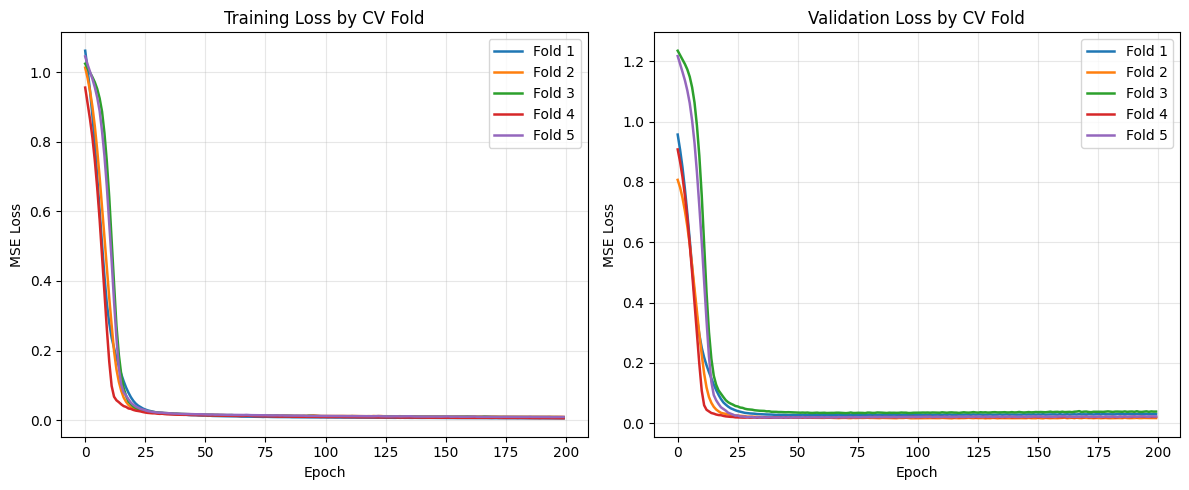

In [19]:
K = 5  # number of folds
fold_size = len(X_cv_raw) // K
fold_indices = [np.arange(i * fold_size, (i + 1) * fold_size) for i in range(K)]
# Assign remainder examples to the last fold
if K * fold_size < len(X_cv_raw):
    fold_indices[-1] = np.arange((K - 1) * fold_size, len(X_cv_raw))
cv_rmses = []
cv_train_curves = []
cv_val_curves = []
for fold in range(K):
    # --- Split this fold ---
    val_idx   = fold_indices[fold]
    train_idx = np.concatenate([fold_indices[j] for j in range(K) if j != fold])
    # --- Normalize (fit on training fold only) ---
    (X_tr_n, y_tr_n, X_val_n, y_val_n,
     X_mean, X_std, y_mean, y_std) = normalize(
        X_cv_raw[train_idx], y_cv_raw[train_idx],
        X_cv_raw[val_idx],   y_cv_raw[val_idx],
    )
    # --- Build DataLoader and tensors ---
    train_loader = make_loader(X_tr_n, y_tr_n)
    X_val_t = torch.tensor(X_val_n, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_n, dtype=torch.float32).unsqueeze(1)
    # --- Train this fold ---
    torch.manual_seed(fold)  # reproducible initialization per fold
    model = make_model(n_hidden_layers=3)
    train_losses, val_losses = train_model(model, train_loader, X_val_t, y_val_t)
    cv_train_curves.append(train_losses)
    cv_val_curves.append(val_losses)
    # --- Compute RMSE in original units ---
    model.eval()
    with torch.no_grad():
        pred_norm = model(X_val_t).squeeze().numpy()
    pred_orig = pred_norm * y_std + y_mean  # denormalize
    fold_rmse = np.sqrt(np.mean((y_cv_raw[val_idx] - pred_orig) ** 2))
    cv_rmses.append(fold_rmse)
    print(f"Fold {fold + 1}: val RMSE = {fold_rmse:.2f} sec")
print(f"\nCV RMSE: {np.mean(cv_rmses):.2f} +/- {np.std(cv_rmses):.2f} sec")

# Plot cross-validation loss curves across folds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for fold, losses in enumerate(cv_train_curves, start=1):
    axes[0].plot(losses, linewidth=1.8, label=f"Fold {fold}")
axes[0].set_title("Training Loss by CV Fold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for fold, losses in enumerate(cv_val_curves, start=1):
    axes[1].plot(losses, linewidth=1.8, label=f"Fold {fold}")
axes[1].set_title("Validation Loss by CV Fold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Interpreting the Cross-Validation Loss Plots

The two plots above show how the neural network learns during **5-fold cross-validation**.

- The **left plot** shows the **training loss** for each fold.
- The **right plot** shows the **validation loss** for each fold.

In plain language, **loss** measures how wrong the model is. A **lower loss** means the predictions are closer to the true picking times. Because this is a regression problem, the loss shown here is **mean squared error (MSE)**, so larger mistakes are penalized more strongly.

Each colored line corresponds to one fold of cross-validation. In each fold, the model is trained on 4 parts of the data and evaluated on the remaining held-out part, as described in [@ml2:cross-validation]. This lets us check whether performance is consistent across different train/validation splits instead of depending on just one split.

These plots show several important things:

- **The loss drops very quickly in the first few epochs.**
  This means the network learns the main structure of the problem early in training.
- **The training loss becomes very small for all folds.**
  So the model can fit the training data well.
- **The validation loss also drops quickly and stays low.**
  This is important because it means the model is not only memorizing the training data; it is also performing well on unseen validation examples.
- **The fold-to-fold curves are similar, but not identical.**
  That is normal. Each fold uses a slightly different subset of the data, so the exact loss values change a little. The fact that the curves have similar shapes suggests the model is behaving consistently across splits.
- **There is no strong sign of overfitting in these plots.**
  If overfitting were severe, the training loss would keep decreasing while the validation loss would rise or stay much higher. Here, the validation curves remain low and stable after the initial drop.

Overall, these plots suggest that the neural network trains stably, converges quickly, and generalizes reasonably well across the different cross-validation folds. That interpretation matches the reported cross-validation RMSE values, which are fairly consistent from fold to fold.

## Task 4: Retraining and Final Evaluation

Cross-validation provides a reliable estimate of the model’s **generalization error**.

After completing cross-validation, we:

- **Retrain the model on the full cross-validation (CV) pool**  
  - This maximizes the amount of data available for training.
- **Evaluate the retrained model on the held-out test set**  
  - The test set was **never used** during training or model selection.

We report the **final RMSE** on this held-out test set as the definitive measure of model performance.

In [14]:
# Normalize using full CV pool statistics
(X_cv_n, y_cv_n, X_test_n, y_test_n,
 X_mean, X_std, y_mean, y_std) = normalize(
    X_cv_raw, y_cv_raw, X_test_raw, y_test_raw,
)
full_loader = make_loader(X_cv_n, y_cv_n)
X_test_t = torch.tensor(X_test_n, dtype=torch.float32)
y_test_t = torch.tensor(y_test_n, dtype=torch.float32).unsqueeze(1)
torch.manual_seed(0)
final_model = make_model(n_hidden_layers=3)
train_losses, test_losses = train_model(
    final_model, full_loader, X_test_t, y_test_t,
)
# Denormalize predictions and compute final RMSE
final_model.eval()
with torch.no_grad():
    test_pred_norm = final_model(X_test_t).squeeze().numpy()
test_pred_orig = test_pred_norm * y_std + y_mean
nn_rmse = np.sqrt(np.mean((y_test_raw - test_pred_orig) ** 2))
print(f"Final test RMSE (neural network): {nn_rmse:.2f} sec")

Final test RMSE (neural network): 2.72 sec


## Task 5: Linear Baseline Comparison

As a baseline, we fit **ordinary least squares (OLS)**—the linear regression model described in [@ml3:linear-regression]—using the **same normalized data** as the neural network.

This is the same class of model that [@ml3:limits-of-linearity] showed **cannot learn XOR**.

In this setting, the linear model likewise fails to capture key nonlinear structure, including:

- The **interaction between congestion and distance**
- The **threshold effect in battery level**

This comparison highlights the limitations of linear models and motivates the use of nonlinear architectures.
``

In [15]:
# OLS via normal equation: w = (X^T X)^{-1} X^T y
X_cv_aug   = np.column_stack([X_cv_n,   np.ones(len(X_cv_n))])    # add bias column
X_test_aug = np.column_stack([X_test_n, np.ones(len(X_test_n))])
w_lin = np.linalg.lstsq(X_cv_aug, y_cv_n, rcond=None)[0]
# Predict and denormalize
y_pred_lin_norm = X_test_aug @ w_lin
y_pred_lin_orig = y_pred_lin_norm * y_std + y_mean
lin_rmse = np.sqrt(np.mean((y_test_raw - y_pred_lin_orig) ** 2))
print(f"Linear baseline test RMSE: {lin_rmse:.2f} sec")
print(f"Neural network test RMSE:  {nn_rmse:.2f} sec")
print(f"MSE improvement: {(1 - (nn_rmse / lin_rmse) ** 2) * 100:.1f}%")

Linear baseline test RMSE: 5.45 sec
Neural network test RMSE:  2.72 sec
MSE improvement: 75.1%


## Task 6: Predicted vs. Actual Plots

Predicted vs. actual plots provide a visual assessment of model performance.

- Points lying close to the **diagonal line** indicate **accurate predictions**.

The **linear model** exhibits clear **systematic errors**:

- It **under-predicts** for **high-congestion / far-distance** cases, where the interaction between features dominates
- It completely **misses the battery-level threshold effect**

In contrast, the **neural network** learns these nonlinear patterns automatically through its hidden layers, as described in [@dl1:multilayer-networks].

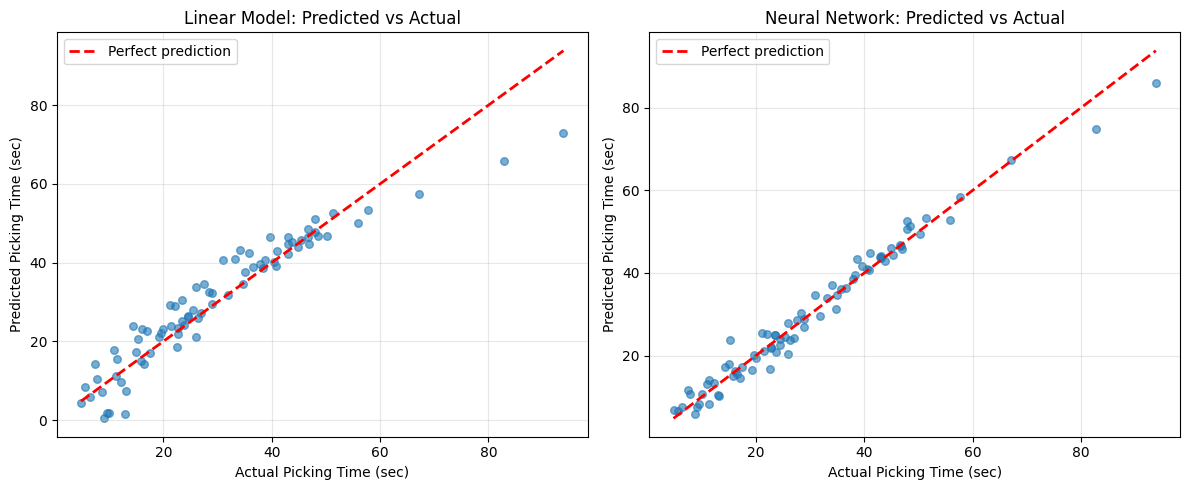

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Model: Predicted vs Actual
ax = axes[0]
ax.scatter(y_test_raw, y_pred_lin_orig, alpha=0.6, s=30)
y_min, y_max = y_test_raw.min(), y_test_raw.max()
ax.plot([y_min, y_max], [y_min, y_max], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Picking Time (sec)')
ax.set_ylabel('Predicted Picking Time (sec)')
ax.set_title('Linear Model: Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

# Neural Network: Predicted vs Actual
ax = axes[1]
ax.scatter(y_test_raw, test_pred_orig, alpha=0.6, s=30)
ax.plot([y_min, y_max], [y_min, y_max], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Picking Time (sec)')
ax.set_ylabel('Predicted Picking Time (sec)')
ax.set_title('Neural Network: Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparing the Predicted-vs.-Actual Plots

The two plots above show the same idea for two different models: for each test example, the horizontal position gives the **actual** picking time and the vertical position gives the model’s **predicted** picking time.

The dashed diagonal line represents **perfect predictions**. If a point lies exactly on that line, the model predicted the picking time exactly right. The farther a point is from the line, the larger the prediction error.

The **linear model** plot shows a clear overall trend, so the model has learned some useful structure in the data. As actual picking time increases, predicted picking time also tends to increase. However, many points are spread farther from the diagonal, especially at the low and high ends of the range. This means the linear model captures the general direction of the relationship, but it does not model the full shape of the true function very well.

A particularly important pattern in the linear plot is that it tends to make **systematic errors** rather than just random small mistakes. For larger actual picking times, many points fall **below** the diagonal, which means the model is **under-predicting** slow or difficult cases. In other words, when the picking task becomes more complex, the linear model often predicts values that are too low. That is consistent with the fact that the true data-generating process includes nonlinear effects that a plain linear model cannot represent directly.

The **neural network** plot is tighter around the diagonal. This means its predictions are usually closer to the true values. The points still are not perfectly on the line, since there is noise in the dataset and no model is exact, but the overall scatter is smaller. The neural network is therefore making smaller errors on average.

The improvement is most noticeable in the parts of the plot where the linear model struggles:

- **At higher picking times**, the neural network stays closer to the diagonal, so it handles more difficult cases better.
- **At the extremes of the range**, the neural network shows less consistent bias than the linear model.
- **Across the middle range**, both models do reasonably well, but the neural network is still more tightly clustered around the ideal line.

In plain language, the comparison says this: the linear model gets the broad trend right, but it is too simple to capture the interaction effects, threshold effects, and curvature in the data. The neural network does a better job matching those nonlinear patterns, so its predictions line up more closely with the actual outcomes.

This visual conclusion matches the numerical results as well: the neural network has a lower RMSE than the linear model, so the better-looking scatter plot is not just cosmetic; it reflects genuinely better predictive accuracy.

## Task 7: Depth Experiment

The **universal approximation theorem** ([@dl1:universal-approximation]) guarantees that a neural network with **a single hidden layer** can approximate the target function, given sufficient width.

However, as noted by [@cmt:universal-approximation], **additional depth can be more parameter‑efficient** than increasing width alone.

In this experiment, we evaluate whether **adding hidden layers** improves performance for this specific dataset.

- Models with different depths are compared
- **Cross-validation** is used to ensure a **fair and reliable comparison**

This allows us to empirically assess whether increased depth provides practical benefits beyond theoretical guarantees.
``

Using **cross-validation**, we compare neural networks with different depths:

- **1 hidden layer** with width **32**
- **2 hidden layers** with widths **[32, 16]**
- **3 hidden layers** with widths **[32, 16, 8]**

For each architecture:

- We compute validation loss across folds
- We plot the **mean validation loss curves** for all three models

This comparison allows us to evaluate whether **increased depth improves performance** for this dataset.

Finally, we interpret the results in the context of the **depth vs. width trade-off**, relating our empirical findings to the discussion in **Comment 6.2**.

1 hidden layer(s): CV RMSE = 2.44 +/- 0.24 sec
2 hidden layer(s): CV RMSE = 2.61 +/- 0.39 sec
3 hidden layer(s): CV RMSE = 2.64 +/- 0.37 sec


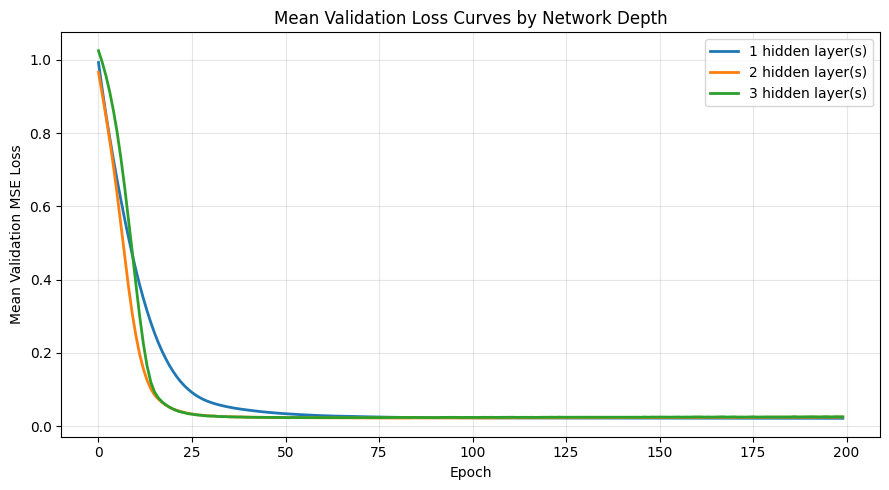

In [18]:
depth_cv_rmses = {}
depth_val_curves = {}
for n_layers in [1, 2, 3]:
    fold_rmses = []
    fold_curves = []
    for fold in range(K):
        val_idx   = fold_indices[fold]
        train_idx = np.concatenate([fold_indices[j] for j in range(K) if j != fold])
        (X_tr_n, y_tr_n, X_v_n, y_v_n,
         _, _, ym, ys) = normalize(
            X_cv_raw[train_idx], y_cv_raw[train_idx],
            X_cv_raw[val_idx],   y_cv_raw[val_idx],
        )
        loader = make_loader(X_tr_n, y_tr_n)
        Xvt = torch.tensor(X_v_n, dtype=torch.float32)
        yvt = torch.tensor(y_v_n, dtype=torch.float32).unsqueeze(1)
        torch.manual_seed(fold)
        m = make_model(n_layers)
        _, vloss = train_model(m, loader, Xvt, yvt)
        fold_curves.append(vloss)
        # Denormalize and compute fold RMSE
        m.eval()
        with torch.no_grad():
            p = m(Xvt).squeeze().numpy() * ys + ym
        fold_rmses.append(np.sqrt(np.mean((y_cv_raw[val_idx] - p) ** 2)))
    mean_rmse = np.mean(fold_rmses)
    std_rmse  = np.std(fold_rmses)
    depth_cv_rmses[n_layers] = (mean_rmse, std_rmse)
    depth_val_curves[n_layers] = np.mean(fold_curves, axis=0)
    print(f"{n_layers} hidden layer(s): CV RMSE = {mean_rmse:.2f} +/- {std_rmse:.2f} sec")

# Plot mean validation loss curves for all three depths
plt.figure(figsize=(9, 5))
for n_layers in [1, 2, 3]:
    plt.plot(depth_val_curves[n_layers], linewidth=2, label=f"{n_layers} hidden layer(s)")
plt.xlabel("Epoch")
plt.ylabel("Mean Validation MSE Loss")
plt.title("Mean Validation Loss Curves by Network Depth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

rmse_comparison = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Neural Network"],
        "Test RMSE (sec)": [lin_rmse, nn_rmse],
    }
)
rmse_comparison["Relative to Linear"] = (
    rmse_comparison["Test RMSE (sec)"] / lin_rmse
)
rmse_comparison["RMSE Improvement vs Linear (%)"] = [
    0.0,
    (1 - nn_rmse / lin_rmse) * 100,
]
rmse_comparison.style.format(
    {
        "Test RMSE (sec)": "{:.2f}",
        "Relative to Linear": "{:.3f}",
        "RMSE Improvement vs Linear (%)": "{:.2f}",
    }
)

,Model,Test RMSE (sec),Relative to Linear,RMSE Improvement vs Linear (%)
0,Linear Regression,5.45,1.000,0.00
1,Neural Network,2.72,0.499,50.12


## Discussion and Interpretation

The results from the notebook are consistent across several views of model performance.

First, the **cross-validation loss curves** and the reported **cross-validation RMSE** show that the neural network trains stably and generalizes well across folds. This follows the purpose of cross-validation discussed in [@ml2:cross-validation]: we are not relying on a single lucky split, but instead evaluating performance repeatedly across held-out folds.

Second, the **predicted-vs.-actual scatter plots** provide a visual comparison between the linear baseline and the neural network. Predictions that lie close to the diagonal correspond to small error. The neural-network scatter is more tightly concentrated around this diagonal, especially at larger picking times, indicating that it captures structure that the linear model misses.

Third, the **linear-vs.-NN RMSE comparison** confirms the visual result numerically: the neural network achieves a lower test RMSE than ordinary least squares. This is expected because the baseline from [@ml3:linear-regression] can only learn an affine relationship in the original inputs, while a multilayer neural network can represent nonlinear functions through compositions of linear layers and nonlinear activations [@dl1:multilayer-networks].

The **depth experiment curves** add a more detailed picture. The mean validation-loss curves for 1, 2, and 3 hidden layers show how model depth affects optimization and validation behavior over training epochs. In this notebook, deeper models do not automatically guarantee better performance; instead, the experiment shows that architecture choice should be validated empirically. This is consistent with the discussion that additional depth can improve expressive power, but its practical benefit depends on the task and data [@cmt:universal-approximation].

The neural network improves most over the linear model in the parts of the input space where the target function is explicitly **nonlinear**:

- **High distance with high congestion**: the target includes an interaction term (`congestion * distance`), which a plain linear model cannot represent without manually engineered interaction features.
- **Low battery values**: the target includes a threshold-style penalty when `battery < 0.2`, which is not naturally captured by a linear model.
- **Larger distances**: the quadratic distance term introduces curvature, again favoring a nonlinear model.

Taken together, the CV loss curves, the predicted-vs.-actual scatter plots, the RMSE comparison, and the depth experiment all support the same conclusion: the neural network is better suited than linear regression for this warehouse picking-time problem because the underlying data-generating process is not purely linear.